# Live Credit-Risk Prediction Demo|

## 1. Setup

In [1]:
from pathlib import Path
import json

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Find the project root whether this notebook is run from ./ or ./notebooks
cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd

DATA_DIR = PROJECT_ROOT / "data"
MODEL_DIR = PROJECT_ROOT / "models"

FEATURE_PATH = DATA_DIR / "application_features.parquet"
SPLIT_PATH = DATA_DIR / "split_assignments.parquet"
MODEL_PATH = MODEL_DIR / "credit_scoring_feature_pipeline.pkl"

required = [FEATURE_PATH, SPLIT_PATH, MODEL_PATH]
missing = [str(p) for p in required if not p.exists()]

if missing:
    raise FileNotFoundError(
        "Required project artifacts are missing:\n- "
        + "\n- ".join(missing)
        + "\n\nRun the training pipeline first: python run_pipeline.py"
    )

print(f"Project root: {PROJECT_ROOT}")
print("Required artifacts found.")


Project root: C:\Users\ashym\Documents\GitHub\jarvis_data_eng_YashMehrotra\ML_1
Required artifacts found.


## 2. Load the saved Pipeline and holdout data

In [2]:
bundle = joblib.load(MODEL_PATH)

pipeline = bundle["pipeline"]
decision_threshold = float(bundle["decision_threshold"])
input_features = bundle["input_features"]

features = pd.read_parquet(FEATURE_PATH)
splits = pd.read_parquet(SPLIT_PATH)[["SK_ID_CURR", "SPLIT"]]

data = features.merge(
    splits,
    on="SK_ID_CURR",
    how="inner",
    validate="one_to_one",
)

holdout = data[data["SPLIT"].eq("test")].copy()
X_holdout = holdout[input_features].copy()

# Match the dtype used during model evaluation
if "CUSTOMER_SEGMENT" in X_holdout.columns:
    X_holdout["CUSTOMER_SEGMENT"] = X_holdout["CUSTOMER_SEGMENT"].astype("string")

print(f"Saved decision threshold: {decision_threshold:.4f}")
print(f"Model input features: {len(input_features):,}")
print(f"Holdout applicants available for demo: {len(holdout):,}")


Saved decision threshold: 0.6885
Model input features: 190
Holdout applicants available for demo: 61,503


## 3. Use a fixed applicant for the live demo

The demo is intentionally locked to **SK_ID_CURR 220485** from the untouched holdout set.

This makes the presentation reproducible: every run uses the same applicant rather than searching for a new example. The following prediction cell also verifies the expected visible result and will stop with an error if the saved model or feature artifacts have changed.


In [3]:
# Lock the live demo to one specific holdout applicant so every run
# uses the same row. This avoids selecting a different applicant if
# ordering or surrounding data changes.

DEMO_APPLICANT_ID = 220485

matches = holdout.index[holdout["SK_ID_CURR"].eq(DEMO_APPLICANT_ID)]
if len(matches) != 1:
    raise ValueError(
        f"Expected exactly one holdout row for applicant {DEMO_APPLICANT_ID}, "
        f"but found {len(matches)}."
    )

demo_index = matches[0]
demo_id = int(holdout.loc[demo_index, "SK_ID_CURR"])
demo_row = X_holdout.loc[[demo_index]].copy()

print(f"Locked demo applicant: {demo_id}")


Locked demo applicant: 220485


## 4. Make prediction

In [4]:
default_probability = float(pipeline.predict_proba(demo_row)[:, 1][0])
risk_class = "HIGHER RISK" if default_probability >= decision_threshold else "LOWER RISK"

# These are the values shown in the submitted live-demo run and presentation.
# The checks intentionally fail if the saved model/data artifacts change enough
# to produce a different visible demo result.
EXPECTED_DISPLAY_PROBABILITY = "75.0%"
EXPECTED_THRESHOLD = 0.6885
EXPECTED_RISK_CLASS = "HIGHER RISK"

display_probability = f"{default_probability:.1%}"

assert display_probability == EXPECTED_DISPLAY_PROBABILITY, (
    f"Demo probability changed: expected {EXPECTED_DISPLAY_PROBABILITY}, "
    f"got {display_probability}. Check that you are using the same saved "
    "model and engineered data artifacts."
)
assert np.isclose(decision_threshold, EXPECTED_THRESHOLD, atol=5e-5), (
    f"Decision threshold changed: expected {EXPECTED_THRESHOLD:.4f}, "
    f"got {decision_threshold:.4f}."
)
assert risk_class == EXPECTED_RISK_CLASS, (
    f"Risk class changed: expected {EXPECTED_RISK_CLASS}, got {risk_class}."
)

result = pd.DataFrame(
    {
        "Applicant ID": [demo_id],
        "Predicted default risk": [default_probability],
        "Project threshold": [decision_threshold],
        "Risk classification": [risk_class],
    }
)

display(
    result.style
    .format(
        {
            "Predicted default risk": "{:.1%}",
            "Project threshold": "{:.2%}",
        }
    )
    .hide(axis="index")
)

print("Demo result verified: applicant 220485 -> 75.0% -> HIGHER RISK")


Applicant ID,Predicted default risk,Project threshold,Risk classification
220485,75.0%,68.85%,HIGHER RISK


Demo result verified: applicant 220485 -> 75.0% -> HIGHER RISK


## 5. Explain with SHAP

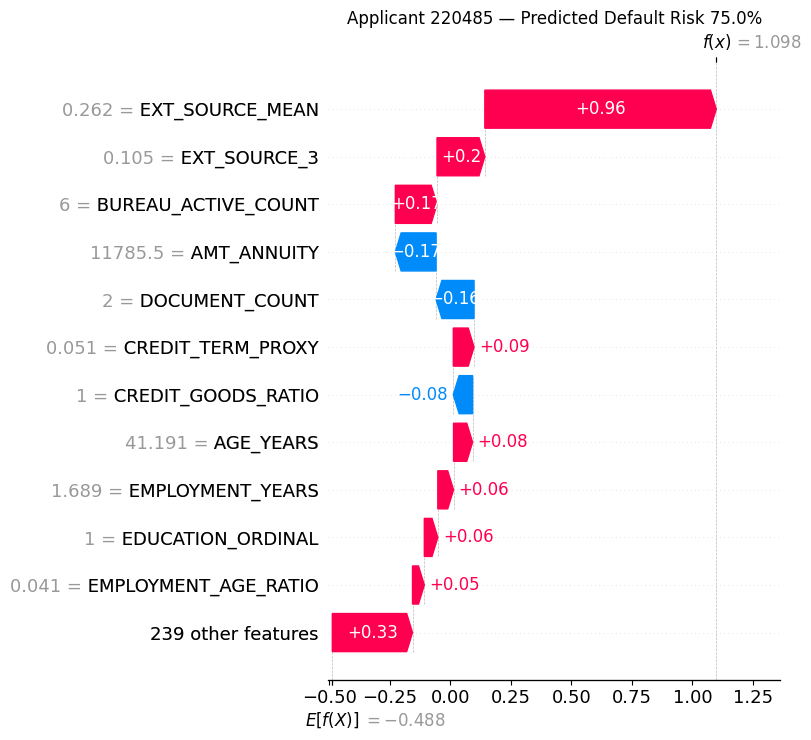

In [5]:
try:
    import shap
except ImportError as exc:
    raise ImportError(
        "SHAP is required for the explanation cell. Install it with: pip install shap"
    ) from exc

preprocessor = pipeline.named_steps["preprocessor"]
model = pipeline.named_steps["model"]

feature_names = np.asarray(preprocessor.get_feature_names_out(), dtype=str)

transformed = preprocessor.transform(demo_row)
if hasattr(transformed, "toarray"):
    transformed = transformed.toarray()
transformed = np.asarray(transformed)

explainer = shap.TreeExplainer(model)
explanation = explainer(transformed, check_additivity=False)
explanation.feature_names = feature_names.tolist()
explanation.data = transformed

shap.plots.waterfall(explanation[0], max_display=12, show=False)
plt.title(
    f"Applicant {demo_id} — Predicted Default Risk {default_probability:.1%}"
)
plt.tight_layout()
plt.show()


## 6. Relevant raw engineered values

In [ ]:
candidate_features = [
    "EXT_SOURCE_MEAN",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
    "AGE_YEARS",
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "BUREAU_RECORD_COUNT",
    "BUREAU_DEBT_CREDIT_RATIO",
]

available = [c for c in candidate_features if c in demo_row.columns]

if available:
    display(demo_row[available].T.rename(columns={demo_index: "Applicant value"}))
else:
    print("None of the optional display features are present in this model schema.")


,Applicant value
EXT_SOURCE_MEAN,0.261550
EXT_SOURCE_1,NaN
EXT_SOURCE_2,0.418305
EXT_SOURCE_3,0.104795
CREDIT_INCOME_RATIO,2.040000
ANNUITY_INCOME_RATIO,0.104760
AGE_YEARS,41.190965
AMT_INCOME_TOTAL,112500.000000
AMT_CREDIT,229500.000000
BUREAU_RECORD_COUNT,10.000000


: 